In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/taiwan_real_estate2.csv=4.csv.xls')

In [3]:
df.head()

,dist_to_mrt_m,n_convenience,house_age_years,price_twd_msq
0,84.87882,10,30 to 45,11.467474
1,306.59470,9,15 to 30,12.768533
2,561.98450,5,0 to 15,14.311649
3,561.98450,5,0 to 15,16.580938
4,390.56840,5,0 to 15,13.040847


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dist_to_mrt_m    414 non-null    float64
 1   n_convenience    414 non-null    int64  
 2   house_age_years  414 non-null    object 
 3   price_twd_msq    414 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 13.1+ KB


In [5]:
df.shape

(414, 4)

In [6]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
409,False
410,False
411,False
412,False


In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
df=df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,dist_to_mrt_m,n_convenience,price_twd_msq
count,412.000000,412.000000,412.000000
mean,1088.225472,4.080097,11.465931
std,1263.612240,2.942414,4.109816
min,23.382840,0.000000,2.299546
25%,289.324800,1.000000,8.350983
50%,492.231300,4.000000,11.618759
75%,1455.798000,6.000000,14.054463
max,6488.021000,10.000000,35.552194


In [11]:
df.isnull().sum()

,0
dist_to_mrt_m,0
n_convenience,0
house_age_years,0
price_twd_msq,0


In [12]:
(df.isnull().sum()/len(df))*100

,0
dist_to_mrt_m,0.0
n_convenience,0.0
house_age_years,0.0
price_twd_msq,0.0


In [13]:
df.dtypes

,0
dist_to_mrt_m,float64
n_convenience,int64
house_age_years,object
price_twd_msq,float64


In [14]:
df.columns

Index(['dist_to_mrt_m', 'n_convenience', 'house_age_years', 'price_twd_msq'], dtype='object')

<Axes: xlabel='dist_to_mrt_m', ylabel='price_twd_msq'>

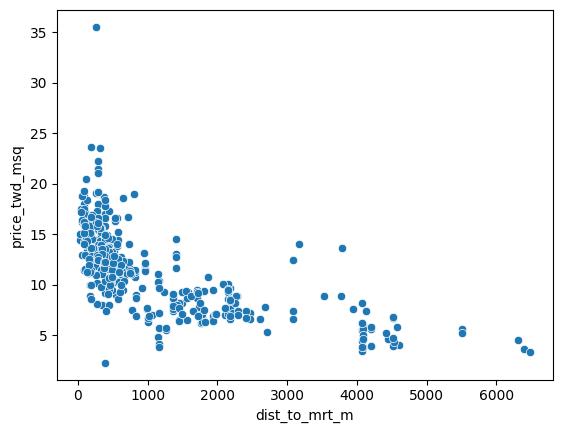

In [15]:
sns.scatterplot(x='dist_to_mrt_m',y='price_twd_msq',data=df)

<Axes: xlabel='n_convenience', ylabel='price_twd_msq'>

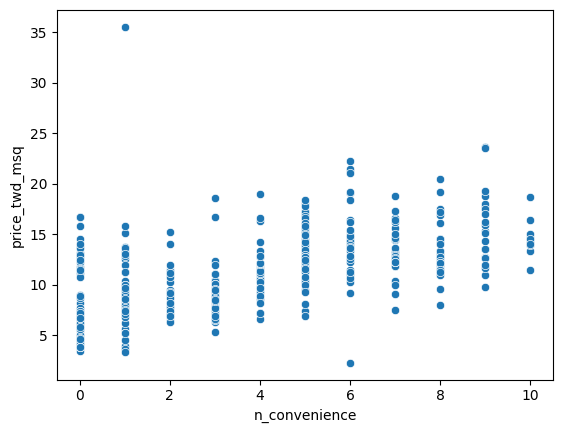

In [16]:
sns.scatterplot(x='n_convenience',y='price_twd_msq',data=df)

<Axes: xlabel='house_age_years', ylabel='price_twd_msq'>

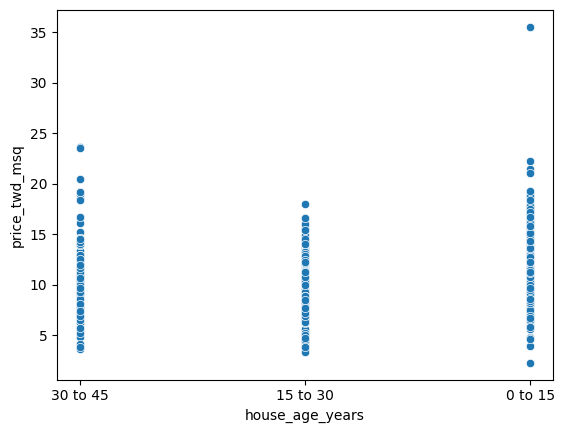

In [17]:
sns.scatterplot(x='house_age_years',y='price_twd_msq',data=df)

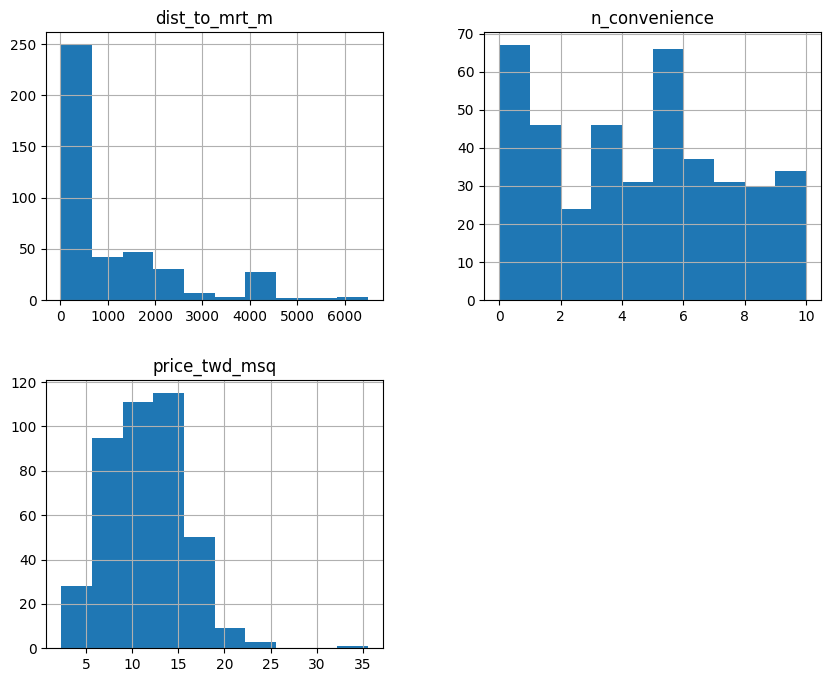

In [18]:
df.hist(figsize=(10,8))
plt.show()

<Axes: >

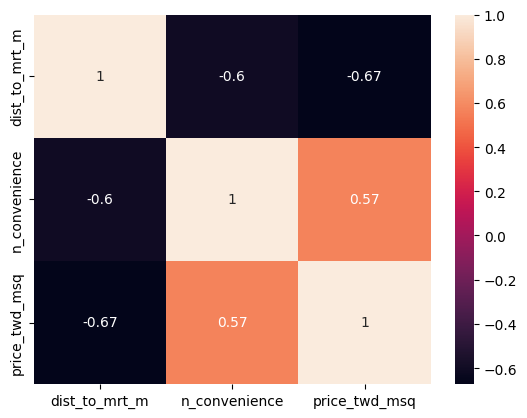

In [19]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),annot=True)

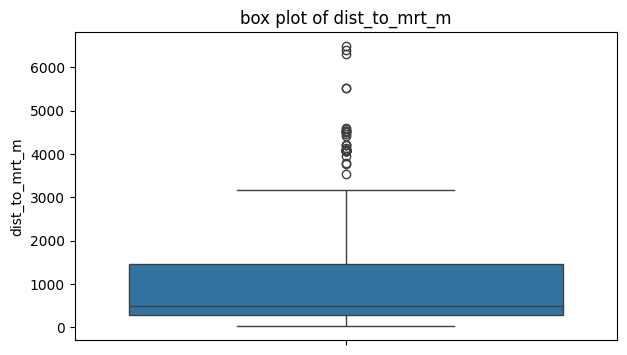

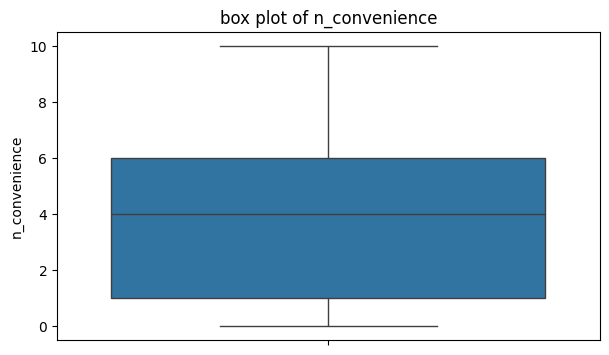

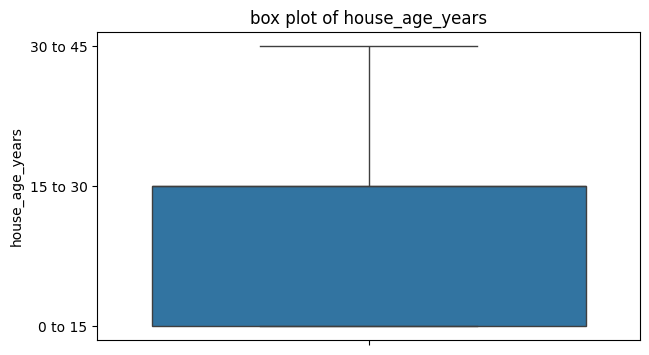

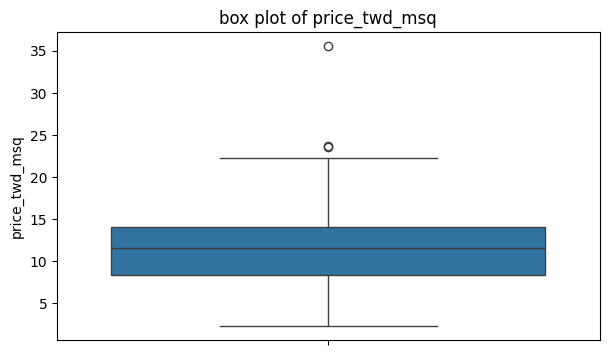

In [20]:
cols=['dist_to_mrt_m','n_convenience','house_age_years','price_twd_msq']
for col in cols:
  plt.figure(figsize=(7,4))
  sns.boxplot(y=df[col])
  plt.title(f'box plot of {col}')
  plt.show()

In [21]:
X=df[['dist_to_mrt_m','n_convenience','house_age_years']]
y=df[['price_twd_msq']]

In [45]:
X=pd.get_dummies(X,drop_first=True)

In [46]:
df['house_age_years']=df['house_age_years'].replace({
    "0 to 15":7.5,
    "15 to 30":22.5,
    "30 to 45":37.5
})

In [47]:
print(X.columns)
print(X.dtypes)

Index(['dist_to_mrt_m', 'n_convenience', 'house_age_years_15 to 30',
       'house_age_years_30 to 45'],
      dtype='object')
dist_to_mrt_m               float64
n_convenience                 int64
house_age_years_15 to 30       bool
house_age_years_30 to 45       bool
dtype: object


In [48]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [49]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [50]:
y_pred=model.predict(X_test)

In [51]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.4115448052705929

In [52]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

9.004975551319331

In [53]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_pred)

2.0935983733647383

In [54]:
print('Intercept:',model.intercept_)
print('Coefficients:',model.coef_)

Intercept: [12.6377445]
Coefficients: [[-1.57024890e-03  3.90263992e-01 -1.78352827e+00 -1.91704272e+00]]


Text(0.5, 1.0, 'Actual Price vs Predicted House Price ')

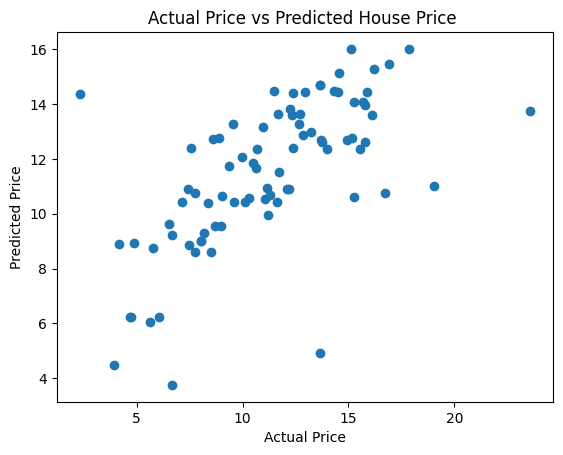

In [55]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Price vs Predicted House Price ')

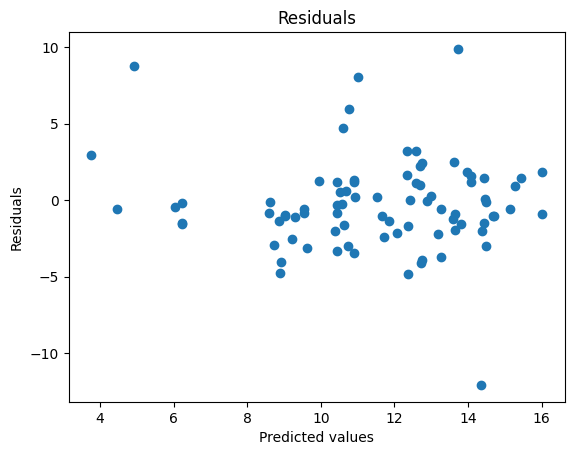

In [57]:
residuals = y_test - y_pred
plt.scatter(y_pred,residuals)
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals')
plt.show()